### 使用开源 LLM 在 Intel CPU 上本地运行的自定义 RAG Agent 工作流程

This article demonstrates how to set up a custom Retrieval-Augmented Generation (RAG) agent workflow using open-source Large Language Models (LLMs) that run locally on Intel CPUs. This approach offers a cost-effective and privacy-preserving alternative to cloud-based solutions.

本文演示了如何使用在 Intel CPU 上本地运行的开源大型语言模型 (LLM) 来设置自定义检索增强生成 (RAG) Agent 工作流程。这种方法为基于云的解决方案提供了一种经济高效且注重隐私的替代方案。

**Prerequisites**

*   **Hardware:** A computer with an Intel CPU. While a GPU can significantly speed up LLM inference, this guide focuses on CPU-only execution.
*   **Software:**
    *   Python 3.8+
    *   `pip` package manager
    *   Basic familiarity with the command line.

**先决条件**

*   **硬件：** 配备 Intel CPU 的计算机。虽然 GPU 可以显著加快 LLM 推理速度，但本指南侧重于仅 CPU 执行。
*   **软件：**
    *   Python 3.8+
    *   `pip` 包管理器
    *   熟悉命令行。

**Step 1: Set up your Python Environment**

First, create a virtual environment to manage your project dependencies.

```bash
python -m venv venv
source venv/bin/activate  # On Windows use `venv\Scripts\activate`
```

**步骤 1：设置您的 Python 环境**

首先，创建一个虚拟环境来管理您的项目依赖项。

```bash
python -m venv venv
source venv/bin/activate  # 在 Windows 上使用 `venv\Scripts\activate`
```

**Step 2: Install Necessary Libraries**

Install the required Python libraries. We'll use `langchain` for orchestrating the RAG workflow, `transformers` for loading and running LLMs, and `sentence-transformers` for generating embeddings.

```bash
pip install langchain transformers sentence-transformers torch accelerate
```

**步骤 2：安装必要的库**

安装所需的 Python 库。我们将使用 `langchain` 来编排 RAG 工作流程，使用 `transformers` 来加载和运行 LLM，并使用 `sentence-transformers` 来生成嵌入。

```bash
pip install langchain transformers sentence-transformers torch accelerate
```

**Step 3: Choose and Download an LLM**

For CPU execution, smaller, quantized models are generally preferred. We'll use a model from the Hugging Face Hub. A good starting point is a model like `all-MiniLM-L6-v2` for embeddings and a smaller LLM for generation.

For this example, let's use `facebook/opt-125m` as our LLM. You can explore other models on the Hugging Face Hub.

**步骤 3：选择并下载 LLM**

对于 CPU 执行，通常首选更小、量化的模型。我们将使用 Hugging Face Hub 中的模型。一个好的起点是像 `all-MiniLM-L6-v2` 这样的模型用于嵌入，以及一个更小的 LLM 用于生成。

在本示例中，我们使用 `facebook/opt-125m` 作为我们的 LLM。您可以在 Hugging Face Hub 上探索其他模型。

**Step 4: Create the RAG Workflow Script**

Create a Python file (e.g., `rag_agent.py`) and add the following code:

```python
import os
from langchain.llms import HuggingFacePipeline
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.chains import RetrievalQA
from langchain.document_loaders import TextLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# --- Configuration ---
LLM_MODEL_NAME = "facebook/opt-125m"
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
DOCUMENT_PATH = "data.txt"
QUERY = "What is RAG?"

# --- Create a dummy document ---
if not os.path.exists(DOCUMENT_PATH):
    with open(DOCUMENT_PATH, "w") as f:
        f.write("Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.")

# --- Load and Process Documents ---
loader = TextLoader(DOCUMENT_PATH)
documents = loader.load()

text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
texts = text_splitter.split_documents(documents)

# --- Initialize Embeddings ---
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL_NAME)

# --- Create Vector Store ---
db = FAISS.from_documents(texts, embeddings)
retriever = db.as_retriever()

# --- Load LLM ---
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(LLM_MODEL_NAME)

# Create a text generation pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=100,
    device=-1 # Use -1 for CPU
)

llm = HuggingFacePipeline(pipeline=pipe)

# --- Create RAG Chain ---
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=retriever,
    chain_type_kwargs={"verbose": True}
)

# --- Run the Query ---
print(f"Query: {QUERY}")
result = qa_chain({"query": QUERY})
print(f"Result: {result['result']}")

```

**步骤 4：创建 RAG 工作流程脚本**

创建一个 Python 文件（例如 `rag_agent.py`）并添加以下代码：

```python
import os
from langchain.llms import HuggingFacePipeline
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.chains import RetrievalQA
from langchain.document_loaders import TextLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# --- 配置 ---
LLM_MODEL_NAME = "facebook/opt-125m"
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
DOCUMENT_PATH = "data.txt"
QUERY = "What is RAG?"

# --- 创建一个虚拟文档 ---
if not os.path.exists(DOCUMENT_PATH):
    with open(DOCUMENT_PATH, "w") as f:
        f.write("Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.")

# --- 加载和处理文档 ---
loader = TextLoader(DOCUMENT_PATH)
documents = loader.load()

text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
texts = text_splitter.split_documents(documents)

# --- 初始化嵌入 ---
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL_NAME)

# --- 创建向量存储 ---
db = FAISS.from_documents(texts, embeddings)
retriever = db.as_retriever()

# --- 加载 LLM ---
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(LLM_MODEL_NAME)

# 创建文本生成管道
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=100,
    device=-1 # 使用 -1 表示 CPU
)

llm = HuggingFacePipeline(pipeline=pipe)

# --- 创建 RAG 链 ---
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=retriever,
    chain_type_kwargs={"verbose": True}
)

# --- 运行查询 ---
print(f"Query: {QUERY}")
result = qa_chain({"query": QUERY})
print(f"Result: {result['result']}")

```

**Explanation:**

1.  **Configuration:** Sets up model names, document path, and the query.
2.  **Dummy Document:** Creates a simple `data.txt` file if it doesn't exist, containing information about RAG.
3.  **Load and Process Documents:** Uses `TextLoader` to load the document, then `CharacterTextSplitter` to break it into smaller chunks.
4.  **Initialize Embeddings:** Loads the `all-MiniLM-L6-v2` model for creating text embeddings.
5.  **Create Vector Store:** Uses FAISS to create an in-memory vector store from the document chunks and embeddings. This allows for efficient similarity search.
6.  **Load LLM:** Loads the specified LLM (`facebook/opt-125m`) and its tokenizer. It then creates a `text-generation` pipeline, explicitly setting `device=-1` to ensure it runs on the CPU.
7.  **Create RAG Chain:** Initializes a `RetrievalQA` chain, combining the LLM with the retriever. The `chain_type_kwargs={"verbose": True}` will print intermediate steps.
8.  **Run Query:** Executes the defined query against the RAG chain and prints the result.

**说明：**

1.  **配置：** 设置模型名称、文档路径和查询。
2.  **虚拟文档：** 如果 `data.txt` 文件不存在，则创建一个简单的文件，其中包含有关 RAG 的信息。
3.  **加载和处理文档：** 使用 `TextLoader` 加载文档，然后使用 `CharacterTextSplitter` 将其分解为更小的块。
4.  **初始化嵌入：** 加载 `all-MiniLM-L6-v2` 模型以创建文本嵌入。
5.  **创建向量存储：** 使用 FAISS 从文档块和嵌入创建内存中的向量存储。这允许进行高效的相似性搜索。
6.  **加载 LLM：** 加载指定的 LLM（`facebook/opt-125m`）及其分词器。然后创建一个 `text-generation` 管道，明确设置 `device=-1` 以确保其在 CPU 上运行。
7.  **创建 RAG 链：** 初始化一个 `RetrievalQA` 链，将 LLM 与检索器结合起来。`chain_type_kwargs={"verbose": True}` 将打印中间步骤。
8.  **运行查询：** 对 RAG 链执行定义的查询并打印结果。

**Step 5: Run the Script**

Make sure you have `data.txt` in the same directory or modify the `DOCUMENT_PATH`. Then, run the script from your terminal:

```bash
python rag_agent.py
```

You should see output similar to this:

```
Query: What is RAG?
Query: What is RAG?
> Entering new Retrieval chain...
> Created a prompt in prompt layer:
Prompt:
Human: Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to find an answer.
NOTE: If you ask a question that is not related to the context, the answer will be "I don't know".

Context: Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.

Question: What is RAG?
Assistant:
Human: Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to find an answer.
NOTE: If you ask a question that is not related to the context, the answer will be "I don't know".

Context: Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.

Question: What is RAG?
Assistant: Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.
> Finished chain.
Result: Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.
```

**步骤 5：运行脚本**

确保 `data.txt` 与脚本在同一目录中，或者修改 `DOCUMENT_PATH`。然后，从终端运行脚本：

```bash
python rag_agent.py
```

您应该会看到类似以下的输出：

```
Query: What is RAG?
Query: What is RAG?
> Entering new Retrieval chain...
> Created a prompt in prompt layer:
Prompt:
Human: Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to find an answer.
NOTE: If you ask a question that is not related to the context, the answer will be "I don't know".

Context: Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.

Question: What is RAG?
Assistant:
Human: Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to find an answer.
NOTE: If you ask a question that is not related to the context, the answer will be "I don't know".

Context: Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.

Question: What is RAG?
Assistant: Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.
> Finished chain.
Result: Retrieval-Augmented Generation (RAG) is a technique for improving the quality of responses from large language models (LLMs). It works by retrieving relevant documents from a knowledge base and then using those documents to augment the prompt given to the LLM. This allows the LLM to generate more informed and accurate answers.
```

**Customization and Further Steps**

*   **Your Own Documents:** Replace `data.txt` with your own text files. You can load multiple documents using `DirectoryLoader`.
*   **Different LLMs:** Experiment with other LLMs available on Hugging Face Hub. For better performance on CPU, consider models that are specifically quantized (e.g., using GGML or GGUF formats, though this requires different libraries like `ctransformers` or `llama-cpp-python`).
*   **Embedding Models:** Try different sentence transformer models for potentially better retrieval accuracy.
*   **Vector Stores:** Explore other vector stores like ChromaDB or Pinecone for more persistent storage and advanced features.
*   **Prompt Engineering:** Modify the prompts used within the `RetrievalQA` chain for better control over the LLM's output.

This setup provides a foundational understanding of building RAG workflows locally. You can expand upon this by integrating more sophisticated retrieval strategies, document processing techniques, and LLM configurations.

**自定义和后续步骤**

*   **您自己的文档：** 将 `data.txt` 替换为您自己的文本文件。您可以使用 `DirectoryLoader` 加载多个文档。
*   **不同的 LLM：** 尝试 Hugging Face Hub 上提供的其他 LLM。为了在 CPU 上获得更好的性能，请考虑专门量化的模型（例如，使用 GGML 或 GGUF 格式，但这需要 `ctransformers` 或 `llama-cpp-python` 等不同的库）。
*   **嵌入模型：** 尝试不同的句子转换器模型，以获得更好的检索准确性。
*   **向量存储：** 探索 ChromaDB 或 Pinecone 等其他向量存储，以获得更持久的存储和高级功能。
*   **提示工程：** 修改 `RetrievalQA` 链中使用的提示，以更好地控制 LLM 的输出。

此设置提供了在本地构建 RAG 工作流程的基础知识。您可以通过集成更复杂的检索策略、文档处理技术和 LLM 配置来扩展此功能。

作者 - Pratool Bharti (pratool.bharti@intel.com)

本笔记本演示了一个检索增强生成（RAG）代理，该代理通过两条路径路由问题以查找答案。该代理根据从向量数据库或网络搜索中检索到的文档生成答案。如果向量数据库缺少相关信息，代理将选择网络搜索。用于 LLM 和嵌入的开源模型在 Intel Xeon CPU 上本地运行，以执行此管道。

<figure style="text-align: center;">
<figcaption style="text-align: center;">Custom RAG Agent 工作流程图</figcaption>
<img src=" “(Formatted RAG)”%20ZWRnZSUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIwcmVsYXRpdmUlM0QlMjIxJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMTIlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjBlZGdlJTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB3aWR0aCUzRCUyMjUwJTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjByZWxhdGl2ZSUzRCUyMjElMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI2MzAlMjIlMjB5JTNEJTIyMTgwJTIyJTIwYXMlM0QlMjJzb3VyY2VQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214UG9pbnQlMjB4JTNEJTIyNjMwJTIyJTIweSUzRCUyMjEzMCUyMiUyMGFzJTNEJTIydGFyZ2V0UG9pbnQlMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteEdlb21ldHJ5JTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0xMyUyMiUyMHZhbHV1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQmV4aXRYJTNEMSUzQmV4aXRYJTNEMCUzQmV4aXREeCUzRDAlM0JlbnRyeVglM0QwLjUlM0JlbnRyeVklM0QxJTNCZW50cnlEeCUzRDAlM0JlbnRyeUR5JTNEMCUzQmV4aXRQZXJpbWV0ZXIlM0QwJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHNvdXJjZSUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTEwJTIyJTIwZWRnZSUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIwd2lkdGglM0QlMjI1MCUyMiUyMGhlaWdodCUzRCUyMjUwJTIyJTIwcmVsYXRpdmUlM0QlMjIxJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214UG9pbnQlMjB4JTNEJTIyNTUwJTIyJTIweSUzRCUyMjIxMCUyMiUyMGFzJTNEJTIyc291cmNlUG9pbnQlMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjU5MCUyMiUyMHklM0QlMjIxOTAlMjIlMjBhcyUzRCUyMnRhcmdldFBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhHZW9tZXRyeSUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjElMjIlMjB2YWx1ZSUzRCUyMk5vJTIyJTIwc3R5bGUlM0QlMjJlZGdlTGFiZWwlN0JodG1sJTNEMSUzQWFsaWduJTNEY2VudGVyJTNCdmVydGljYWxBbGlnbiUzRG1pZGRsZSU3QnJlc2l6YWJsZSUzRDAlM0Jwb2ludHMlM0QlNUIlNUQlM0IlMjIlMjBwYXJlbnQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0xMyUyMiUyMHZlcnRleCUzRCUyMjElMjIlMjBjb25uZWN0YWJsZSUzRCUyMjAlMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMi0wLjA2NzIlMjIlMjByZWxhdGl2ZSUzRCUyMjElMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMGFzJTNEJTIyb2Zmc2V0JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhHZW9tZXRyeSUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMTQlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjBlZGdlJTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB3aWR0aCUzRCUyMjUwJTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjByZWxhdGl2ZSUzRCUyMjElMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI1NTAlMjIlMjB5JTNEJTIyMTYwJTIyJTIwYXMlM0QlMjJzb3VyY2VQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214UG9pbnQlMjB4JTNEJTIyNTkwJTIyJTIweSUzRCUyMjEzMCUyMiUyMGFzJTNEJTIydGFyZ2V0UG9pbnQlMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteEdlb21ldHJ5JTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMCUyMiUyMHZhbHV1ZSUzRCUyIlllcyUyMiUyMHN0eWxlJTNEJTIyZWRnZUxhYmVsJTNCaHRtbCUzRDElM0JhbGlnbiUzRGNlbnRlciUzQnZlcnRpY2FsQWxpZ24lM0RtaWRkbGUlM0JyZXNpemFibGUlM0QwJTNCcG9pbnRzJTNEJTVCJTVEJTNCJTIyJTIwcGFyZW50JTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMTQlMjIlMjB2ZXJ0ZXglM0QlMjIxJTIyJTIwY29ubmVjdGFibGUlM0QlMjIwJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHglM0QlMjItMC4wNDk2JTIyJTIweSUzRCUyMi0xJTIyJTIwcmVsYXRpdmUlM0QlMjIxJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214UG9pbnQlMjBhcyUzRCUyMm9mZnNldCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE4JTIyJTIwdmFsdWUlM0QlMjJSQUclMjBQcm9tcHQlMjB3aXRoJTIwcmVsZXZhbnQlMjBkb2NzJTIyJTIwc3R5bGUlM0QlMjJyb3VuZGVkJTNEMSUzQndoaXRlU3BhY2UlM0R3cmFwJTNCaHRtbCUzRDElM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwdmVydGV4JTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB4JTNEJTIyNTkwJTIyJTIweSUzRCUyMjkwJTIyJTIwd2lkdGglM0QlMjIxMDAlMjIlMjBoZWlnaHQlM0QlMjI0MCUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTIwdmFsdWUlM0QlMjJXZWIlMjBTZWFyY2glMjIlMjBzdHlsZSUzRCUyMnJvdW5kZWQlM0QxJTNCd2hpdGVTcGFjZSUzRHdyYXAlN0JodG1sJTNEMSUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB2ZXJ0ZXglM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHglM0QlMjI1OTAlMjIlMjB5JTNEJTIyMTkwJTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQwJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjMlMjIlMjB2YWx1ZSUzRCUyMlJlc3BvbnNlJTIyJTIwc3R5bGUlM0QlMjJzdHJva2VXaWR0aCUzRDIlM0JodG1sJTNEMSUzQnNoYXBlJTNEbXhncmFwaC5mbG93Y2hhcnQudGVybWluYXRvciUzQndoaXRlU3BhY2UlM0R3cmFwJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjYwJTIyJTIweSUzRCUyMjI3NS41JTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQ1JTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCcm91bmRlZCUzRDAlM0JlbnRyeVglM0QwLjUlM0JlbnRyeVklM0QxJTNCZW50cnlEeCUzRDAlM0JlbnRyeUR5JTNEMCUzQmV4aXRYJTNEMC41JTNCZXhpdFklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0JleGl0UGVyaW1ldGVyJTNEMCUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjY5MCUyMiUyMHklM0QlMjIxMTAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI3NDAlMjIlMjB5JTNEJTIyNjAlMjIlMjBhcyUzRCUyMnRhcmdldFBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhHZW9tZXRyeSUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjclMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCUzRDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjQ1MiUzQmV4aXRYJTNEMCUzQmV4aXRYJTNEMCUzQmV4aXREeCUzRDAlM0JlbnRyeVBlcmltZXRlciUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMiUyMiUyMHRhcmdldCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTUlMjIlMjBlZGdlJTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB3aWR0aCUzRCUyMjUwJTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjByZWxhdGl2ZSUzRCUyMjElMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjIyNTAlMjIlMjB5JTNEJTIyMjIwJTIyJTIwYXMlM0QlMjJzb3VyY2VQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214UG9pbnQlMjB4JTNEJTIyMjkwJTIyJTIweSUzRCUyMjE3MCUyMiUyMGFzJTNEJTIydGFyZ2V0UG9pbnQlMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NBcnJheSUyMGFzJTNEJTIycG9pbnRzJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjIyNDclMjIlMjB5JTNEJTIyMjIwJTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJ FQXJyYXklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteEdlb21ldHJ5JTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yOCUyMiUyMHZhbHVlJTNEJTIyR3JhZGUlMjBkb2N1bWVudHMlMjBieSUyMExMTSUyMiUyMHN0eWxlJTNEJTIyc2hhcGUlM0Rwcm9jZXNzJTNCd2hpdGVTcGFjZSUzRHdyYXAlN0JodG1sJTNEMSUzQmJhY2tncm91bmRPdXRsaW5lJTNE1JTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjQ0My43NSUyMiUyMHklM0QlMjIzMzMlMjIlMjB3aWR0aCUzRCUyMjEyMi41JTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yOSUyMiUyMHZhbHVlJTNEJTIyJTIyJTIwc3R5bGUlM0QlMjJlbmRBcnJvdyUzRGNsYXNzaWMlM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCUzRDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjUlM0JlbnRyeVklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjglMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0xMCUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjUwMCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI1NTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMkIxWTk5b25IODJtaTdOZjhPOEdmLTAlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQiUyMiUyMGVkZ2UlM0QlMjIxJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHNvdXJjZSUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjYzMCUyMiUyMHklM0QlMjIxODAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI2MzAlMjIlMjB5JTNEJTIyMTMwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE4JTIyJTIwdmFsdWUlM0QlMjJSQUclMjBQcm9tcHQlMjB3aXRoJTIwcmVsZXZhbnQlMjBkb2NzJTIyJTIwc3R5bGUlM0QlMjJyb3VuZGVkJTNEMSUzQndoaXRlU3BhY2UlM0R3cmFwJTNCaHRtbCUzRDElM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwdmVydGV4JTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB4JTNEJTIyNTkwJTIyJTIweSUzRCUyMjkwJTIyJTIwd2lkdGglM0QlMjIxMDAlMjIlMjBoZWlnaHQlM0QlMjI0MCUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTIwdmFsdWUlM0QlMjJXZWIlMjBTZWFyY2glMjIlMjBzdHlsZSUzRCUyMnJvdW5kZWQlM0QxJTNCd2hpdGVTcGFjZSUzRHdyYXAlN0JodG1sJTNEMSUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB2ZXJ0ZXglM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHglM0QlMjI1OTAlMjIlMjB5JTNEJTIyMTkwJTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQwJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjMlMjIlMjB2YWx1ZSUzRCUyMlJlc3BvbnNlJTIyJTIwc3R5bGUlM0QlMjJzdHJva2VXaWR0aCUzRDIlM0JodG1sJTNEMSUzQnNoYXBlJTNEbXhncmFwaC5mbG93Y2hhcnQudGVybWluYXRvciUzQndoaXRlU3BhY2UlM0R3cmFwJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjYwJTIyJTIweSUzRCUyMjI3NS41JTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQ1JTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCcm91bmRlZCUzRDAlM0JlbnRyeVglM0QwLjUlM0JlbnRyeVklM0QxJTNCZW50cnlEeCUzRDAlM0JlbnRyeUR5JTNEMCUzQmV4aXRYJTNEMC41JTNCZXhpdFklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0JleGl0UGVyaW1ldGVyJTNEMCUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjY5MCUyMiUyMHklM0QlMjIxMTAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI3NDAlMjIlMjB5JTNEJTIyNjAlMjIlMjBhcyUzRCUyMnRhcmdldFBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhHZW9tZXRyeSUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjclMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCUzRDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjQ1MiUzQmV4aXRYJTNEMCUzQmV4aXREeCUzRDAlM0JlbnRyeVBlcmltZXRlciUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjI1MCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjIyOTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTI4JTIyJTIwdmFsdWUlM0QlMjJEcmF3JTIwZG9jdW1lbnRzJTIyJTIwc3R5bGUlM0QlMjJzaGFwZSUzRHByb2Nlc3MlN0J3aGl0ZVNwYWNlJTNEd3JhcCU3Qmh0bWwlM0QxJTNCYmFja2dyb3VuZE91dGxpbmUlM0QxJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjQ0My43NSUyMiUyMHklM0QlMjIzMzMlMjIlMjB3aWR0aCUzRCUyMjEyMi41JTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yOSUyMiUyMHZhbHVlJTNEJTIyJTIyJTIwc3R5bGUlM0QlMjJlbmRBcnJvdyUzRGNsYXNzaWMlM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjUlM0JlbnRyeVklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjglMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0xMCUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjUwMCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI1NTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMkIxWTk5b25IODJtaTdOZjhPOEdmLTAlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQiUyMiUyMGVkZ2UlM0QlMjIxJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHNvdXJjZSUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjYzMCUyMiUyMHklM0QlMjIxODAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI2MzAlMjIlMjB5JTNEJTIyMTMwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE4JTIyJTIwdmFsdWUlM0QlMjJSQUclMjBQcm9tcHQlMjB3aXRoJTIwcmVsZXZhbnQlMjBkb2NzJTIyJTIwc3R5bGUlM0QlMjJyb3VuZGVkJTNEMSUzQndoaXRlU3BhY2UlM0R3cmFwJTNCaHRtbCUzRDElM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwdmVydGV4JTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB4JTNEJTIyNTkwJTIyJTIweSUzRCUyMjkwJTIyJTIwd2lkdGglM0QlMjIxMDAlMjIlMjBoZWlnaHQlM0QlMjI0MCUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTIwdmFsdWUlM0QlMjJXZWIlMjBTZWFyY2glMjIlMjBzdHlsZSUzRCUyMnJvdW5kZWQlM0QxJTNCd2hpdGVTcGFjZSUzRHdyYXAlN0JodG1sJTNEMSUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB2ZXJ0ZXglM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHglM0QlMjI1OTAlMjIlMjB5JTNEJTIyMTkwJTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQwJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjMlMjIlMjB2YWx1ZSUzRCUyMlJlc3BvbnNlJTIyJTIwc3R5bGUlM0QlMjJzdHJva2VXaWR0aCUzRDIlM0JodG1sJTNEMSUzQnNoYXBlJTNEbXhncmFwaC5mbG93Y2hhcnQudGVybWluYXRvciUzQndoaXRlU3BhY2UlM0R3cmFwJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjYwJTIyJTIweSUzRCUyMjI3NS41JTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQ1JTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCcm91bmRlZCUzRDAlM0JlbnRyeVglM0QwLjUlM0JlbnRyeVklM0QxJTNCZW50cnlEeCUzRDAlM0JlbnRyeUR5JTNEMCUzQmV4aXRYJTNEMC41JTNCZXhpdFklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0JleGl0UGVyaW1ldGVyJTNEMCUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjY5MCUyMiUyMHklM0QlMjIxMTAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI3NDAlMjIlMjB5JTNEJTIyNjAlMjIlMjBhcyUzRCUyMnRhcmdldFBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhHZW9tZXRyeSUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjclMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjQ1MiUzQmV4aXRYJTNEMCUzQmV4aXREeCUzRDAlM0JlbnRyeVBlcmltZXRlciUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjI1MCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjIyOTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTI4JTIyJTIwdmFsdWUlM0QlMjJEcmF3JTIwZG9jdW1lbnRzJTIyJTIwc3R5bGUlM0QlMjJzaGFwZSUzRHByb2Nlc3MlN0J3aGl0ZVNwYWNlJTNEd3JhcCU3Qmh0bWwlM0QxJTNCYmFja2dyb3VuZE91dGxpbmUlM0QxJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjQ0My43NSUyMiUyMHklM0QlMjIzMzMlMjIlMjB3aWR0aCUzRCUyMjEyMi41JTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yOSUyMiUyMHZhbHVlJTNEJTIyJTIyJTIwc3R5bGUlM0QlMjJlbmRBcnJvdyUzRGNsYXNzaWMlM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjUlM0JlbnRyeVklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjglMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0xMCUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjUwMCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI1NTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE4JTIyJTIwdmFsdWUlM0QlMjJSQUclMjBQcm9tcHQlMjB3aXRoJTIwcmVsZXZhbnQlMjBkb2NzJTIyJTIwc3R5bGUlM0QlMjJyb3VuZGVkJTNEMSUzQndoaXRlU3BhY2UlM0R3cmFwJTNCaHRtbCUzRDElM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwdmVydGV4JTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB4JTNEJTIyNTkwJTIyJTIweSUzRCUyMjkwJTIyJTIwd2lkdGglM0QlMjIxMDAlMjIlMjBoZWlnaHQlM0QlMjI0MCUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTIwdmFsdWUlM0QlMjJXZWIlMjBTZWFyY2glMjIlMjBzdHlsZSUzRCUyMnJvdW5kZWQlM0QxJTNCd2hpdGVTcGFjZSUzRHdyYXAlN0JodG1sJTNEMSUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB2ZXJ0ZXglM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHglM0QlMjI1OTAlMjIlMjB5JTNEJTIyMTkwJTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQwJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjMlMjIlMjB2YWx1ZSUzRCUyMlJlc3BvbnNlJTIyJTIwc3R5bGUlM0QlMjJzdHJva2VXaWR0aCUzRDIlM0JodG1sJTNEMSUzQnNoYXBlJTNEbXhncmFwaC5mbG93Y2hhcnQudGVybWluYXRvciUzQndoaXRlU3BhY2UlM0R3cmFwJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjYwJTIyJTIweSUzRCUyMjI3NS41JTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQ1JTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCcm91bmRlZCUzRDAlM0JlbnRyeVglM0QwLjUlM0JlbnRyeVklM0QxJTNCZW50cnlEeCUzRDAlM0JlbnRyeUR5JTNEMCUzQmV4aXRYJTNEMC41JTNCZXhpdFklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0JleGl0UGVyaW1ldGVyJTNEMCUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjY5MCUyMiUyMHklM0QlMjIxMTAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI3NDAlMjIlMjB5JTNEJTIyNjAlMjIlMjBhcyUzRCUyMnRhcmdldFBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhHZW9tZXRyeSUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjclMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjQ1MiUzQmV4aXRYJTNEMCUzQmV4aXREeCUzRDAlM0JlbnRyeVBlcmltZXRlciUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjI1MCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjIyOTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTI4JTIyJTIwdmFsdWUlM0QlMjJEcmF3JTIwZG9jdW1lbnRzJTIyJTIwc3R5bGUlM0QlMjJzaGFwZSUzRHByb2Nlc3MlN0J3aGl0ZVNwYWNlJTNEd3JhcCU3Qmh0bWwlM0QxJTNCYmFja2dyb3VuZE91dGxpbmUlM0QxJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjQ0My43NSUyMiUyMHklM0QlMjIzMzMlMjIlMjB3aWR0aCUzRCUyMjEyMi41JTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yOSUyMiUyMHZhbHVlJTNEJTIyJTIyJTIwc3R5bGUlM0QlMjJlbmRBcnJvdyUzRGNsYXNzaWMlM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjUlM0JlbnRyeVklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjglMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0xMCUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjUwMCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI1NTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE4JTIyJTIwdmFsdWUlM0QlMjJSQUclMjBQcm9tcHQlMjB3aXRoJTIwcmVsZXZhbnQlMjBkb2NzJTIyJTIwc3R5bGUlM0QlMjJyb3VuZGVkJTNEMSUzQndoaXRlU3BhY2UlM0R3cmFwJTNCaHRtbCUzRDElM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwdmVydGV4JTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB4JTNEJTIyNTkwJTIyJTIweSUzRCUyMjkwJTIyJTIwd2lkdGglM0QlMjIxMDAlMjIlMjBoZWlnaHQlM0QlMjI0MCUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTIwdmFsdWUlM0QlMjJXZWIlMjBTZWFyY2glMjIlMjBzdHlsZSUzRCUyMnJvdW5kZWQlM0QxJTNCd2hpdGVTcGFjZSUzRHdyYXAlN0JodG1sJTNEMSUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB2ZXJ0ZXglM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHglM0QlMjI1OTAlMjIlMjB5JTNEJTIyMTkwJTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQwJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjMlMjIlMjB2YWx1ZSUzRCUyMlJlc3BvbnNlJTIyJTIwc3R5bGUlM0QlMjJzdHJva2VXaWR0aCUzRDIlM0JodG1sJTNEMSUzQnNoYXBlJTNEbXhncmFwaC5mbG93Y2hhcnQudGVybWluYXRvciUzQndoaXRlU3BhY2UlM0R3cmFwJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjYwJTIyJTIweSUzRCUyMjI3NS41JTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQ1JTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCcm91bmRlZCUzRDAlM0JlbnRyeVglM0QwLjUlM0JlbnRyeVklM0QxJTNCZW50cnlEeCUzRDAlM0JlbnRyeUR5JTNEMCUzQmV4aXRYJTNEMC41JTNCZXhpdFklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0JleGl0UGVyaW1ldGVyJTNEMCUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjY5MCUyMiUyMHklM0QlMjIxMTAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI3NDAlMjIlMjB5JTNEJTIyNjAlMjIlMjBhcyUzRCUyMnRhcmdldFBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhHZW9tZXRyeSUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjclMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjQ1MiUzQmV4aXRYJTNEMCUzQmV4aXREeCUzRDAlM0JlbnRyeVBlcmltZXRlciUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjI1MCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjIyOTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTI4JTIyJTIwdmFsdWUlM0QlMjJEcmF3JTIwZG9jdW1lbnRzJTIyJTIwc3R5bGUlM0QlMjJzaGFwZSUzRHByb2Nlc3MlN0J3aGl0ZVNwYWNlJTNEd3JhcCU3Qmh0bWwlM0QxJTNCYmFja2dyb3VuZE91dGxpbmUlM0QxJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjQ0My43NSUyMiUyMHklM0QlMjIzMzMlMjIlMjB3aWR0aCUzRCUyMjEyMi41JTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yOSUyMiUyMHZhbHVlJTNEJTIyJTIyJTIwc3R5bGUlM0QlMjJlbmRBcnJvdyUzRGNsYXNzaWMlM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjUlM0JlbnRyeVklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjglMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0xMCUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjUwMCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI1NTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE4JTIyJTIwdmFsdWUlM0QlMjJSQUclMjBQcm9tcHQlMjB3aXRoJTIwcmVsZXZhbnQlMjBkb2NzJTIyJTIwc3R5bGUlM0QlMjJyb3VuZGVkJTNEMSUzQndoaXRlU3BhY2UlM0R3cmFwJTNCaHRtbCUzRDElM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwdmVydGV4JTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB4JTNEJTIyNTkwJTIyJTIweSUzRCUyMjkwJTIyJTIwd2lkdGglM0QlMjIxMDAlMjIlMjBoZWlnaHQlM0QlMjI0MCUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTIwdmFsdWUlM0QlMjJXZWIlMjBTZWFyY2glMjIlMjBzdHlsZSUzRCUyMnJvdW5kZWQlM0QxJTNCd2hpdGVTcGFjZSUzRHdyYXAlN0JodG1sJTNEMSUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB2ZXJ0ZXglM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHglM0QlMjI1OTAlMjIlMjB5JTNEJTIyMTkwJTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQwJTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjMlMjIlMjB2YWx1ZSUzRCUyMlJlc3BvbnNlJTIyJTIwc3R5bGUlM0QlMjJzdHJva2VXaWR0aCUzRDIlM0JodG1sJTNEMSUzQnNoYXBlJTNEbXhncmFwaC5mbG93Y2hhcnQudGVybWluYXRvciUzQndoaXRlU3BhY2UlM0R3cmFwJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjYwJTIyJTIweSUzRCUyMjI3NS41JTIyJTIwd2lkdGglM0QlMjI4MCUyMiUyMGhlaWdodCUzRCUyMjQ1JTIyJTIwYXMlM0QlMjJnZW9tZXRyeSUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCcm91bmRlZCUzRDAlM0JlbnRyeVglM0QwLjUlM0JlbnRyeVklM0QxJTNCZW50cnlEeCUzRDAlM0JlbnRyeUR5JTNEMCUzQmV4aXRYJTNEMC41JTNCZXhpdFklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0JleGl0UGVyaW1ldGVyJTNEMCUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjY5MCUyMiUyMHklM0QlMjIxMTAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI3NDAlMjIlMjB5JTNEJTIyNjAlMjIlMjBhcyUzRCUyMnRhcmdldFBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhHZW9tZXRyeSUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14Q2VsbCUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214Q2VsbCUyMGlkJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjclMjIlMjB2YWx1ZSUzRCUyMiUyMiUyMHN0eWxlJTNEJTIyZW5kQXJyb3clM0RjbGFzc2ljJTNCaHRtbCUzRDElM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjQ1MiUzQmV4aXRYJTNEMCUzQmV4aXREeCUzRDAlM0JlbnRyeVBlcmltZXRlciUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjUlMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yMyUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjI1MCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjIyOTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTI4JTIyJTIwdmFsdWUlM0QlMjJEcmF3JTIwZG9jdW1lbnRzJTIyJTIwc3R5bGUlM0QlMjJzaGFwZSUzRHByb2Nlc3MlN0J3aGl0ZVNwYWNlJTNEd3JhcCU3Qmh0bWwlM0QxJTNCYmFja2dyb3VuZE91dGxpbmUlM0QxJTNCJTIyJTIwcGFyZW50JTNEJTIyV0l5V2xMazZHSlFzcWFVQktUTlYtMSUyMiUyMHZlcnRleCUzRCUyMjElMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteEdlb21ldHJ5JTIweCUzRCUyMjQ0My43NSUyMiUyMHklM0QlMjIzMzMlMjIlMjB3aWR0aCUzRCUyMjEyMi41JTIyJTIwaGVpZ2h0JTNEJTIyNTAlMjIlMjBhcyUzRCUyMmdlb21ldHJ5JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDJTJGbXhDZWxsJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhDZWxsJTIwaWQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0yOSUyMiUyMHZhbHVlJTNEJTIyJTIyJTIwc3R5bGUlM0QlMjJlbmRBcnJvdyUzRGNsYXNzaWMlM0Jyb3VuZGVkJTNEMCUzQmVudHJ5WCUzRDAuNSUzQmVudHJ5WCU3RDElM0JlbnRyeUR4JTNEMCUzQmVudHJ5RHklM0QwJTNCZXhpdFglM0QwLjUlM0JlbnRyeVklM0QwJTNCZXhpdER4JTNEMCUzQmV4aXREeSUzRDAlM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwc291cmNlJTNEJTIyMC1qZ1hqblNOdFBJS1FVVkhKc2ctMjglMjIlMjB0YXJnZXQlM0QlMjIwLWpnWGpuU050UElLUVVWSEpzZy0xMCUyMiUyMGVkZ2UlM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHdpZHRoJTNEJTIyNTAlMjIlMjBoZWlnaHQlM0QlMjI1MCUyMiUyMHJlbGF0aXZlJTNEJTIyMSUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteFBvaW50JTIweCUzRCUyMjUwMCUyMiUyMHklM0QlMjIyMjAlMjIlMjBhcyUzRCUyMnNvdXJjZVBvaW50JTIyJTIwJTJGJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhQb2ludCUyMHglM0QlMjI1NTAlMjIlMjB5JTNEJTIyMTcwJTIyJTIwYXMlM0QlMjJ0YXJnZXRQb2ludCUyMiUyMCUyRiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQyUyRm14R2VvbWV0cnklM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE4JTIyJTIwdmFsdWUlM0QlMjJSQUclMjBQcm9tcHQlMjB3aXRoJTIwcmVsZXZhbnQlMjBkb2NzJTIyJTIwc3R5bGUlM0QlMjJyb3VuZGVkJTNEMSUzQndoaXRlU3BhY2UlM0R3cmFwJTNCaHRtbCUzRDElM0IlMjIlMjBwYXJlbnQlM0QlMjJXSXlXbExrNkdKUXNxYVVCS1ROVi0xJTIyJTIwdmVydGV4JTNEJTIyMSUyMiUzRSUwQSUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUyMCUzQ214R2VvbWV0cnklMjB4JTNEJTIyNTkwJTIyJTIweSUzRCUyMjkwJTIyJTIwd2lkdGglM0QlMjIxMDAlMjIlMjBoZWlnaHQlM0QlMjI0MCUyMiUyMGFzJTNEJTIyZ2VvbWV0cnklMjIlMjAlMkYlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0MlMkZteENlbGwlM0UlMEElMjAlMjAlMjAlMjAlMjAlMjAlMjAlMjAlM0NteENlbGwlMjBpZCUzRCUyMjAtamdYam5TTnRQSUtRVVZISnNnLTE5JTIyJTIwdmFsdWUlM0QlMjJXZWIlMjBTZWFyY2glMjIlMjBzdHlsZSUzRCUyMnJvdW5kZWQlM0QxJTNCd2hpdGVTcGFjZSUzRHdyYXAlN0JodG1sJTNEMSUzQiUyMiUyMHBhcmVudCUzRCUyMldJeVdsTGs2R0pRc3FhVUJLVE5WLTElMjIlMjB2ZXJ0ZXglM0QlMjIxJTIyJTNFJTBBJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTIwJTNDbXhHZW9tZXRyeSUyMHglM0QlMjI1OTAlMjIlMjB5JTNEJTI

在 conda 或 venv 环境中安装所需库

In [1]:
!pip install --upgrade --quiet  tiktoken scikit-learn gpt4all langchain langchain-community langchain-core langchain_nomic langchain_ollama langgraph 


[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


在 Linux 系统中，请使用以下命令安装 Ollama 并下载 Llama 3.1 模型到本地。
```
curl -fsSL https://ollama.com/install.sh | sh
ollama run llama3.1

In [ ]:
"""
This cell asks you to set up environment variables for a local RAG (Retrieval-Augmented Generation) agent.

Environment Variables:
- USER_AGENT: Specifies the user agent string to be used.
- LANGSMITH_TRACING: Enables or disables tracing for LangChain.
- LANGSMITH_API_KEY: API key for accessing LangChain services.
- TAVILY_API_KEY: API key for accessing Tavily services.
"""
import os

os.environ["USER_AGENT"] = "myagent"
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = "xxxx"
os.environ["TAVILY_API_KEY"] = "tvly-xxxx"

使用本地嵌入模型将文档存储在向量数据库中

In [3]:
"""
This cell performs the following tasks:

1. Imports necessary modules and classes from langchain and related libraries.
2. Defines a list of URLs from IRS to load tax related documents from.
3. Loads documents from the specified URLs using the WebBaseLoader.
4. Flattens the list of loaded documents.
5. Initializes a RecursiveCharacterTextSplitter with a specified chunk size and overlap.
6. Splits the loaded documents into chunks using the text splitter.
7. Initializes an SKLearnVectorStore with the document chunks embedded using  local embeddings model "nomic-embed-text-v1.5" from NomicEmbeddings.
8. Converts the vector store into a retriever with a specified number of nearest neighbors (k=4).

Modules and Classes:
- RecursiveCharacterTextSplitter: Splits text into chunks based on character count.
- WebBaseLoader: Loads documents from web URLs.
- SKLearnVectorStore: Stores document vectors for retrieval.
- NomicEmbeddings: Generates embeddings for documents.
- tool: Utility for defining tools.

Variables:
- urls: List of URLs to load documents from.
- docs: List of loaded documents from the URLs.
- docs_list: Flattened list of loaded documents.
- text_splitter: Instance of RecursiveCharacterTextSplitter.
- doc_splits: List of document chunks.
- vectorstore: Instance of SKLearnVectorStore.
- retriever: Retriever instance for querying the vector store.
"""

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import SKLearnVectorStore
from langchain_core.tools import tool
from langchain_nomic.embeddings import NomicEmbeddings

# List of URLs to load documents from
urls = [
    "https://www.irs.gov/newsroom/irs-releases-tax-inflation-adjustments-for-tax-year-2025",
    "https://www.irs.gov/newsroom/401k-limit-increases-to-23500-for-2025-ira-limit-remains-7000",
    "https://www.irs.gov/newsroom/tax-basics-understanding-the-difference-between-standard-and-itemized-deductions",
]

# Load documents from the URLs
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Initialize a text splitter with specified chunk size and overlap
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)

# Split the documents into chunks
doc_splits = text_splitter.split_documents(docs_list)

# Add the document chunks to the "vector store" using NomicEmbeddings
vectorstore = SKLearnVectorStore.from_documents(
    documents=doc_splits,
    embedding=NomicEmbeddings(
        model="nomic-embed-text-v1.5", inference_mode="local", device="cpu"
    ),
    # embedding=OpenAIEmbeddings(),
)
retriever = vectorstore.as_retriever(k=4)

Failed to load libllamamodel-mainline-cuda-avxonly.so: dlopen: libcudart.so.11.0: cannot open shared object file: No such file or directory
Failed to load libllamamodel-mainline-cuda.so: dlopen: libcudart.so.11.0: cannot open shared object file: No such file or directory


In [4]:
"""
This cell imports the necessary modules and initializes the web search tool for the LLM.

Modules:
- `Document` from `langchain.schema`: Represents a document schema.
- `TavilySearchResults` from `langchain_community.tools.tavily_search`: Provides functionality to perform web search by LLM if required.

Initialization:
- `web_search_tool`: An instance of `TavilySearchResults` used to perform web searches.
"""
from langchain.schema import Document
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults()

In [5]:
"""
This cell sets up a question-answering assistant using the LangChain library. 
1. It imports necessary modules: `ChatOllama` for the language model, `PromptTemplate` for creating prompts, and `StrOutputParser` for parsing the output.
2. It defines a prompt template that instructs the assistant to answer questions concisely using provided documents.
3. It initializes the `ChatOllama` language model with specific parameters.
4. It creates a chain (`rag_chain`) that combines the prompt template, language model, and output parser to process and generate answers.
This setup is essential for enabling the assistant to handle question-answering tasks effectively.
"""
from langchain.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

prompt = PromptTemplate(
    template="""You are an assistant for question-answering tasks. 
    
    Use the following documents to answer the question. 
    
    If you don't know the answer, just say that you don't know. 
    
    Use three sentences maximum and keep the answer concise:
    Question: {question} 
    Documents: {documents} 
    Answer: 
    """,
    input_variables=["question", "documents"],
)

llm = ChatOllama(
    model="llama3.1",
    temperature=0,
)

rag_chain = prompt | llm | StrOutputParser()

In [6]:
"""
This cell sets up a prompt template and a retrieval grader for assessing the relevance of a retrieved document to a user question.

Functionality:
- Imports the necessary JsonOutputParser from langchain_core.output_parsers.
- Defines a PromptTemplate that instructs a grader to assess the relevance of a document to a user question.
- The grader uses a simple binary scoring system ('yes' or 'no') to indicate relevance.
- The result is provided as a JSON object with a single key 'score'.
- Combines the prompt template with a language model (llm) and the JsonOutputParser to create the retrieval_grader.

The retrieval_grader can be used in the workflow to filter out erroneous document retrievals based on their relevance to user questions.
"""
from langchain_core.output_parsers import JsonOutputParser

prompt = PromptTemplate(
    template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
    Here is the retrieved document: \n\n {document} \n\n
    Here is the user question: {question} \n
    If the document contains keywords related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question. \n
    Provide the binary score as a JSON with a single key 'score' and no premable or explanation.""",
    input_variables=["question", "document"],
)

retrieval_grader = prompt | llm | JsonOutputParser()

In [7]:
# This cell defines the state of the graph and imports necessary modules for graph visualization.
# It includes a TypedDict class `GraphState` that represents the state of the graph with attributes
# such as question, generation, search, documents, and steps. This state will be used to manage
# the workflow of the RAG agent.

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph
from typing_extensions import List, TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    search: str
    documents: List[str]
    steps: List[str]

In [8]:
# This cell contains the core functions for the document retrieval and answer generation pipeline.
# The functions are designed to work with a state dictionary that maintains the current state of the process.


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    question = state["question"]
    documents = retriever.invoke(question)
    steps = state["steps"]
    steps.append("retrieve_documents")
    return {"documents": documents, "question": question, "steps": steps}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """

    question = state["question"]
    documents = state["documents"]
    generation = rag_chain.invoke({"documents": documents, "question": question})
    steps = state["steps"]
    steps.append("generate_answer")
    return {
        "documents": documents,
        "question": question,
        "generation": generation,
        "steps": steps,
    }


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    question = state["question"]
    documents = state["documents"]
    steps = state["steps"]
    steps.append("grade_document_retrieval")
    filtered_docs = []
    search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score["score"]
        if grade == "yes":
            filtered_docs.append(d)
        else:
            search = "Yes"
            continue
    return {
        "documents": filtered_docs,
        "question": question,
        "search": search,
        "steps": steps,
    }


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    question = state["question"]
    documents = state.get("documents", [])
    steps = state["steps"]
    steps.append("web_search")
    web_results = web_search_tool.invoke({"query": question})
    documents.extend(
        [
            Document(page_content=d["content"], metadata={"url": d["url"]})
            for d in web_results
        ]
    )
    return {"documents": documents, "question": question, "steps": steps}


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """
    search = state["search"]
    if search == "Yes":
        return "search"
    else:
        return "generate"

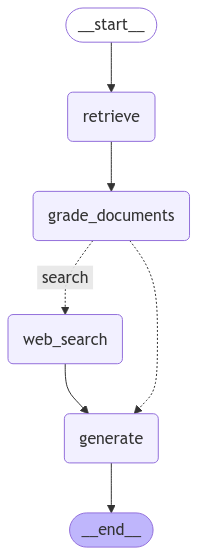

In [11]:
# Graph
"""
This cell defines and builds a state graph workflow for the agent pipeline described earlier.

The workflow consists of the following nodes:
- "retrieve": Retrieves documents from the vector database.
- "grade_documents": Grades the retrieved documents.
- "generate": Generates output based on the graded documents.
- "web_search": Performs a web search if needed.

The workflow is constructed as follows:
1. The entry point is set to the "retrieve" node. so the first step is to retrieve similar documents from the vector database.
2. An edge is added from "retrieve" to "grade_documents".
3. Conditional edges are added from "grade_documents" to either "web_search" or "generate" based on the decision function `decide_to_generate`.
4. An edge is added from "web_search" to "generate".
5. An edge is added from "generate" to the end of the workflow.

Finally, the workflow is compiled into a custom graph and displayed as a Mermaid diagram.
"""
workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("web_search", web_search)  # web search

# Build graph
workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {"search": "web_search", "generate": "generate"},
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("generate", END)

custom_graph = workflow.compile()

display(Image(custom_graph.get_graph(xray=True).draw_mermaid_png()))

In [12]:
import uuid


def predict_custom_agent_answer(example: dict):
    # This cell defines a function to predict the answer from a custom agent based on the provided example input.
    """
    Predicts the answer from a custom agent based on the provided example input.

    Args:
        example (dict): A dictionary containing the input question under the key "input".

    Returns:
        dict: A dictionary containing the response generated by the custom agent under the key "response",
              and the steps taken during the generation process under the key "steps".

    The `config` dictionary is used to pass configuration settings to the custom graph.
    In this case, it includes a unique `thread_id` generated using `uuid.uuid4()`.
    The `thread_id` ensures that each invocation of the function is uniquely identifiable,
    which can be useful for tracing and debugging purposes.
    """

    config = {"configurable": {"thread_id": str(uuid.uuid4())}}

    state_dict = custom_graph.invoke(
        {"question": example["input"], "steps": []}, config
    )

    return {"response": state_dict["generation"], "steps": state_dict["steps"]}

In [13]:
"""
# Here we define an example input question about the difference between standard deduction and itemized deduction,
# and then uses the `predict_custom_agent_answer` function to generate a response based on the input and show it.
# Since, this question is related to tax deductions, the agent should provide an answer based on the loaded tax documents.
"""
example = {
    "input": "What is the difference between standard deduction and itemized deduction?"
}
response = predict_custom_agent_answer(example)
response

{'response': 'The standard deduction is a fixed amount that most taxpayers can claim, while itemized deductions are specific expenses like mortgage interest, charitable donations, and medical expenses that can be deducted from taxable income. Taxpayers choose the option that gives them the lowest overall tax.',
 'steps': ['retrieve_documents',
  'grade_document_retrieval',
  'generate_answer']}

In [14]:
"""
# Here we define another example input question about the sports event,
# and then uses the `predict_custom_agent_answer` function to generate a response based on the input and show it.
# Since, this question is NOT related to tax deductions, the agent should provide an answer based on the documents returned from web search.
"""
example = {"input": "Who won the 2024 cricket world cup and who was the MVP in final?"}
response = predict_custom_agent_answer(example)
response

{'response': 'India won the 2024 cricket world cup and Virat Kohli was named Player of the Match for. The final match was played between India and South Africa on June 29, 2024. India defeated South Africa by 7 runs to win their second T20 World Cup title.',
 'steps': ['retrieve_documents',
  'grade_document_retrieval',
  'web_search',
  'generate_answer']}

正如在之前的示例中所演示的，RAG 代理通过网络搜索来路由控制流，以生成非税务相关问题的答案。对于税务相关查询，它使用从向量数据库检索到的文档。